In [17]:
import pandas as pd

df = pd.read_csv('cohort_final.csv')

In [18]:
df.columns

Index(['EncounterKey', 'PatientDurableKey', 'encounter_date', 'Type',
       'VisitType', 'VisitTypeDescription', 'DepartmentKey',
       'PrimaryDiagnosisKey', 'AttendingProviderDurableKey', 'IsEdVisit',
       'IsHospitalAdmission', 'IsHospitalOutpatientVisit',
       'IsInpatientAdmission', 'IsObservation', 'IsOutpatientFaceToFaceVisit',
       'AdmissionSource', 'AdmissionType', 'DiagnosisValue', 'GroupName',
       'GroupCode', 'OmbRace', 'OmbEthnicity', 'SexAssignedAtBirth',
       'PatientBirthYearBin', 'SmokingStatus', 'MyChartStatus',
       'MaritalStatus', 'CensusBlockGroupFipsCode', 'VitalStatus',
       'approx_age', 'DepartmentName', 'DepartmentSpecialty', 'DepartmentType',
       'City', 'County', 'transport_burdened', 'n_transport_screens',
       'transport_burden_at_encounter', 'sdoh_financial_resource_strain',
       'sdoh_food_insecurity', 'sdoh_housing_stability', 'sdoh_utilities',
       'sdoh_intimate_partner_violance', 'sdoh_stress',
       'journey_encounter_nu

In [42]:
# PatientDurableKey, OmbRace, SexAssignedAtBirth, approx_age, SmokingStatus, 
# transport_burdened, sdoh_financial_resource_strain, sdoh_food_insecurity, 
# sdoh_intimate_partner_violance, sdoh_housing_stability
df_regression = df.loc[:, ['PatientDurableKey', 'OmbRace', 'SexAssignedAtBirth', 'approx_age', 'SmokingStatus', 
                           'transport_burdened', 'sdoh_financial_resource_strain', 'sdoh_food_insecurity',
                           'sdoh_intimate_partner_violance', 'sdoh_housing_stability', 'IsEdVisit']]

df_regression = df_regression.dropna(subset=["SexAssignedAtBirth"])

# Race
race = df_regression["OmbRace"]
df_regression["OmbRace"] = race.case_when([
    (race == "White", "White"),
    (race == "Black or African American", "Black"),
    (race == "Asian", "Asian"),
    (~race.isin(["White", "Black or African American", "Asian"]), "Other"),
])

# Sex
sex = df_regression["SexAssignedAtBirth"]
df_regression["SexAssignedAtBirth"] = sex.case_when([
    (sex == "Male", "Male"),
    (sex == "Female", "Female"),
    (~sex.isin(["Male", "Female"]), "Other"),
])

# Smoking
smoke = df_regression["SmokingStatus"]
df_regression["SmokingStatus"] = smoke.case_when([
    (smoke.isin(["Every Day", "Some Days", "Light Smoker"]), "Smoker"),
    (smoke.isin(["Never", "Former", "Passive Smoke Exposure - Never Smoker"]), "NonSmoker"),
    (~smoke.isin(["Every Day", "Some Days", "Light Smoker",
                  "Never", "Former", "Passive Smoke Exposure - Never Smoker"]), "Other"),
])

collapsed = (
    df_regression.groupby(["PatientDurableKey"])
    .agg(
        EdVisits = ("IsEdVisit", "max"),
        TransportBurdened = ("transport_burdened", "max"),
        Race = ("OmbRace", "first"),
        Sex  = ("SexAssignedAtBirth", "first"),
        Age = ("approx_age", "first"),
        SmokingStatus = ('SmokingStatus', 'first'),
        SDOH_Financial = ("sdoh_financial_resource_strain", "max"),
        SDOH_Food = ("sdoh_food_insecurity", "max"),
        SDOH_Violence = ("sdoh_intimate_partner_violance", "max"),
        SDOH_Stability = ("sdoh_housing_stability", "max"),
    )
    .reset_index()
)

# Check how much variation each SDOH column has
print(collapsed[["TransportBurdened", "SDOH_Financial", "SDOH_Food", 
                  "SDOH_Violence", "SDOH_Stability"]].value_counts())

# Check if any column is nearly all one value
print(collapsed[["TransportBurdened", "SDOH_Financial", "SDOH_Food", 
                  "SDOH_Violence", "SDOH_Stability"]].mean())

# Check EdVisits is actually binary after your max change
print(collapsed["EdVisits"].value_counts())


TransportBurdened  SDOH_Financial  SDOH_Food  SDOH_Violence  SDOH_Stability
0                  0               0          0              0                 19876
                   1               0          0              0                  1061
1                  0               0          0              0                   496
                   1               0          0              0                   315
                                                             1                   248
0                  0               0          1              0                   146
1                  1               0          1              1                   104
0                  1               0          0              1                    69
                                              1              0                    59
1                  1               0          1              0                    55
0                  0               0          0              1            

In [55]:
import statsmodels.formula.api as smf

# Dummy-code categoricals — sets reference categories
# collapsed["Race"] = pd.Categorical(collapsed["Race"], categories=["White", "Black", "Asian", "Other"])
# collapsed["Sex"] = pd.Categorical(collapsed["Sex"], categories=["Male", "Female", "Other"])
# collapsed["SmokingStatus"] = pd.Categorical(collapsed["SmokingStatus"], categories=["NonSmoker", "Smoker", "Other"])

formula = """
    EdVisits ~ TransportBurdened * SDOH_Financial + 
               TransportBurdened * SDOH_Violence + 
               TransportBurdened * SDOH_Stability +
               TransportBurdened * Age + 
               TransportBurdened * Race + 
               TransportBurdened * Sex + 
               TransportBurdened * SmokingStatus
"""

model = smf.logit(formula, data=collapsed).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.649252
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               EdVisits   No. Observations:                22587
Model:                          Logit   Df Residuals:                    22563
Method:                           MLE   Df Model:                           23
Date:                Sun, 12 Apr 2026   Pseudo R-squ.:                 0.05265
Time:                        12:32:14   Log-Likelihood:                -14665.
converged:                       True   LL-Null:                       -15480.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------
Intercept                                    -

In [56]:
import numpy as np

odds = pd.DataFrame({
    "OddsRatio": np.exp(model.params),
    "CI_lower":  np.exp(model.conf_int()[0]),
    "CI_upper":  np.exp(model.conf_int()[1]),
    "pvalue":    model.pvalues
}).round(20)

print(odds)

                                           OddsRatio  CI_lower  CI_upper  \
Intercept                                   0.300112  0.264631  0.340351   
Race[T.Black]                               2.460624  2.181986  2.774843   
Race[T.Asian]                               0.557754  0.393759  0.790050   
Race[T.Other]                               1.286207  1.175412  1.407445   
Sex[T.Female]                               1.182524  1.058835  1.320662   
Sex[T.Other]                                1.049468  0.954787  1.153537   
SmokingStatus[T.Smoker]                     2.267531  2.082404  2.469116   
SmokingStatus[T.Other]                      0.515670  0.308964  0.860668   
TransportBurdened                           2.879177  1.536053  5.396730   
TransportBurdened:Race[T.Black]             0.942437  0.609086  1.458230   
TransportBurdened:Race[T.Asian]             0.319056  0.031787  3.202481   
TransportBurdened:Race[T.Other]             0.736422  0.513280  1.056574   
TransportBur

In [ ]:
import numpy as np

fractures = df[df["GroupCode"].str[11:12] == "S"].loc[:, ['PatientDurableKey', 'IsEdVisit', 'GroupCode', 'transport_burdened', 'transport_burden_at_encounter', 'journey_day']]

collapsed = (
    fractures.groupby(["PatientDurableKey", "GroupCode"])
    .agg(
        EdVisits = ("IsEdVisit", "sum"),
        TransportBurdened = ("transport_burdened", "max"),
        TransportBurdenedEncounter = ("transport_burden_at_encounter", "max"),
        JourneyLength  = ("journey_day", "max")
    )
    .reset_index()
)

collapsed_anal_burdened = collapsed[collapsed["TransportBurdened"] == 1].reset_index(drop=True)
collapsed_anal_non = collapsed[collapsed["TransportBurdened"] == 0].reset_index(drop=True)

print(f"Burdened: {(collapsed_anal_burdened["EdVisits"] >= 1).mean()}")
print(f"Non - Burdened: {(collapsed_anal_non["EdVisits"] >= 1).mean()}")
print(f"Burdened: {len(collapsed_anal_burdened["EdVisits"] >= 1)}")
print(f"Non - Burdened: {len(collapsed_anal_non["EdVisits"] >= 1)}")
collapsed_anal_burdened["EdVisits"]

Burdened: 0.58679706601467
Non - Burdened: 0.32023203504202674
Burdened: 818
Non - Burdened: 8447


0      1
1      0
2      1
3      0
4      0
      ..
813    0
814    1
815    0
816    1
817    0
Name: EdVisits, Length: 818, dtype: int64

Burdened: 87.76841550808733
Non - Burdened: 116.5812893196273
Burdened: 91.09645849245167
Non - Burdened: 103.06058370326323
1305
21349


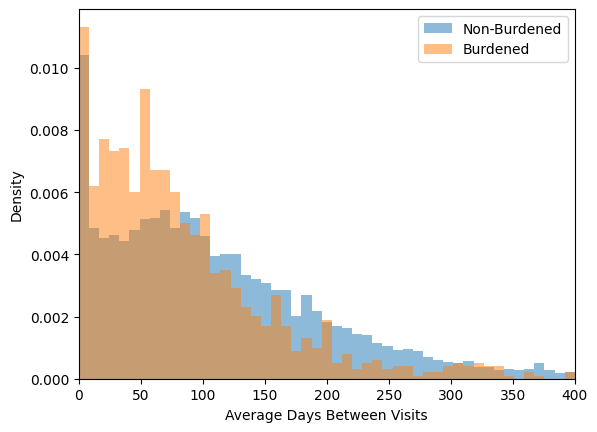

In [107]:
gap_between = df.loc[:, ['PatientDurableKey', 'IsEdVisit', 'transport_burdened', 'transport_burden_at_encounter', 'days_since_last']]

gap_between = (
    gap_between.groupby(["PatientDurableKey"])
    .agg(
        EdVisits = ("IsEdVisit", "sum"),
        TransportBurdened = ("transport_burdened", "max"),
        TransportBurdenedEncounter = ("transport_burden_at_encounter", "max"),
        DaysAvg  = ("days_since_last", "mean")
    )
    .reset_index()
)

gap_between_burdened = gap_between[gap_between["TransportBurdened"] == 1].reset_index(drop=True)
gap_between_non = gap_between[gap_between["TransportBurdened"] == 0].reset_index(drop=True)

print(f"Burdened: {gap_between_burdened["DaysAvg"].mean()}")
print(f"Non - Burdened: {gap_between_non["DaysAvg"].mean()}")
print(f"Burdened: {gap_between_burdened["DaysAvg"].std()}")
print(f"Non - Burdened: {gap_between_non["DaysAvg"].std()}")
print(len(gap_between_burdened))
print(len(gap_between_non))

# gap_between_burdened["DaysAvg"].plot.hist(bins=50, xlim=(0, 500))
# gap_between_non["DaysAvg"].plot.hist(bins=50, xlim=(0, 500))

import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0, 400, 50)

fig, ax = plt.subplots()

ax.hist(gap_between_non["DaysAvg"], bins=bins, alpha=0.5, 
        density=True, label="Non-Burdened")

ax.hist(gap_between_burdened["DaysAvg"], bins=bins, alpha=0.5, 
        density=True, label="Burdened")

ax.set_xlim(0, 400)
ax.set_xlabel("Average Days Between Visits")
ax.set_ylabel("Density")

ax.legend()
plt.show()

<Axes: ylabel='Frequency'>

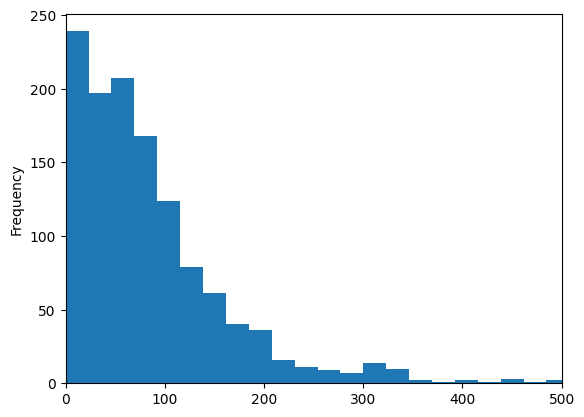

In [87]:
gap_between_burdened["DaysAvg"].plot.hist(bins=50, xlim=(0, 500))

<Axes: ylabel='Frequency'>

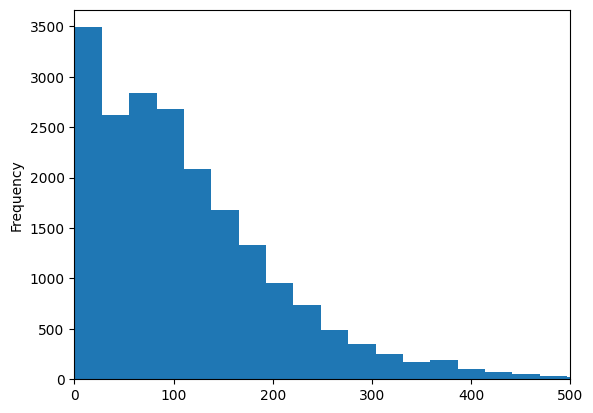

In [88]:
gap_between_non["DaysAvg"].plot.hist(bins=50, xlim=(0, 500))

In [58]:
total_length = df.loc[:, ['PatientDurableKey', 'IsEdVisit', 'transport_burdened', 'transport_burden_at_encounter', 'journey_day']]

collapsed = (
    total_length.groupby(["PatientDurableKey"])
    .agg(
        EdVisits = ("IsEdVisit", "sum"),
        TransportBurdened = ("transport_burdened", "max"),
        TransportBurdenedEncounter = ("transport_burden_at_encounter", "sum"),
        JourneyLength  = ("journey_day", "max")
    )
    .reset_index()
)

collapsed_anal_burdened = collapsed[collapsed["TransportBurdened"] == 1].reset_index(drop=True)
collapsed_anal_non = collapsed[collapsed["TransportBurdened"] == 0].reset_index(drop=True)


print(f"Burdened: {collapsed_anal_burdened["JourneyLength"].mean()}")
print(f"Non - Burdened: {collapsed_anal_non["JourneyLength"].mean()}")

Burdened: 784.3624521072796
Non - Burdened: 766.0783174855965
